In [1]:
import os
import re
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, accuracy_score,  confusion_matrix
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar
import gc
from util import seed_everything

seed_everything(0)

# Statistical helper functions
def delong_roc_test(ground_truth, predictions_one, predictions_two):
    """
    Statistically compares two AUCs. Returns (auc1, auc2, p_value).
    """
    auc1 = roc_auc_score(ground_truth, predictions_one)
    auc2 = roc_auc_score(ground_truth, predictions_two)
    pos_mask, neg_mask = (ground_truth == 1), (ground_truth == 0)
    m, n = np.sum(pos_mask), np.sum(neg_mask)
    def get_components(preds):
        pos_preds, neg_preds = preds[pos_mask], preds[neg_mask]
        v10 = np.array([(np.sum(neg_preds < p) + 0.5 * np.sum(neg_preds == p)) / n for p in pos_preds])
        v01 = np.array([(np.sum(pos_preds > p) + 0.5 * np.sum(pos_preds == p)) / m for p in neg_preds])
        return v10, v01
    v10_1, v01_1 = get_components(predictions_one)
    v10_2, v01_2 = get_components(predictions_two)
    var1 = np.var(v10_1, ddof=1)/m + np.var(v01_1, ddof=1)/n
    var2 = np.var(v10_2, ddof=1)/m + np.var(v01_2, ddof=1)/n
    covariance = np.cov(v10_1, v10_2)[0,1]/m + np.cov(v01_1, v01_2)[0,1]/n
    se = np.sqrt(max(1e-10, var1 + var2 - 2 * covariance))
    z = (auc1 - auc2) / se
    return auc1, auc2, 2 * (1 - norm.cdf(np.abs(z)))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_clinical_metrics(y_true, y_pred_probs):
    preds = (y_pred_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / TPR
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
    auc = roc_auc_score(y_true, y_pred_probs)
    
    return acc, sens, spec, auc

# Models
class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=2, embed_dim=16, n_layers=4):
        super().__init__()
        # Spectral decay coefficients (1/f)
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        # N x d_e expansion, each of the n inputs gets its own direction vector.
        self.mode_weights = nn.Parameter(torch.randn(n_inputs, embed_dim) * 0.02)
        # Positional embeddings to maintain identity of each mode
        self.pos_embed = nn.Parameter(torch.randn(n_inputs, 1, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim * 2, 
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim), 
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        # x shape: [batch, n_inputs]
        b = x.shape[0]
        # Apply spectral weighting (1/f)
        x = x * self.rank_weights
        # Component-Specific Projection:
        # This lifts the sequence into a full-rank subspace.
        x = x.unsqueeze(-1) * self.mode_weights.unsqueeze(0)
        # Prepare for Transformer [seq_len, batch, embed_dim]
        x = x.transpose(0, 1)
        x = x + self.pos_embed
        # Contextualize modes via self-attention
        x = self.transformer(x)
        # Global Average Pooling across the spectral sequence
        x = x.mean(dim=0)
        # Classification head
        return self.mlp_head(x).squeeze(-1)

class SpatialViT(nn.Module):
    def __init__(self, vol_size=96, patch_size=12, embed_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (vol_size // patch_size) ** 3
        self.proj = nn.Linear(patch_size ** 3, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(self.n_patches + 1, 1, embed_dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))

    def forward(self, x):
        b = x.shape[0]
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).unfold(4, p, p).contiguous().view(b, self.n_patches, -1)
        x = self.proj(x).transpose(0, 1)
        cls_tokens = self.cls_token.expand(1, b, -1)
        x = torch.cat((cls_tokens, x), dim=0)
        x = x + self.pos_embed
        x = self.transformer(x)
        return self.mlp_head(x[0]).squeeze(-1)

# Load data
def load_ixi_3d(data_dir, csv_path, crop_size=96):
    df = pd.read_csv(csv_path)
    id_col = [c for c in df.columns if 'ID' in c.upper()][0]
    sex_col = [c for c in df.columns if 'SEX' in c.upper()][0]
    df[id_col] = df[id_col].astype(int)
    sex_lookup = dict(zip(df[id_col], df[sex_col].map({1: 0, 2: 1})))
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.nii.gz')])
    vols, labels = [], []
    for f in tqdm(files):
        match = re.search(r'(\d+)', f)
        if match and int(match.group(1)) in sex_lookup:
            subj_id = int(match.group(1))
            img = nib.load(os.path.join(data_dir, f)).get_fdata()
            pad_widths = [(max(0, (crop_size - s)//2), max(0, (crop_size - s + 1)//2)) for s in img.shape]
            img = np.pad(img, pad_widths, mode='constant')
            c = np.array(img.shape) // 2
            r = crop_size // 2
            crop = img[c[0]-r:c[0]+r, c[1]-r:c[1]+r, c[2]-r:c[2]+r]
            if crop.shape == (crop_size, crop_size, crop_size):
                crop = (crop - np.mean(crop)) / (np.std(crop) + 1e-8)
                vols.append(crop.astype(np.float32)); labels.append(sex_lookup[subj_id])
    return np.array(vols), np.array(labels).astype(np.float32)

# Training loop
MNI_DIR, CSV_PATH = './data/IXI_extracted/', './data/IXI_extracted/IXI.csv'
VOL_SIZE, N_COMP, EPOCHS, BATCH_SIZE = 96, 128, 500, 4
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")

X, Y = load_ixi_3d(MNI_DIR, CSV_PATH, crop_size=VOL_SIZE)
X_flat = X.reshape(len(X), -1)

# Data summary
n_total = len(Y)
n_male = int(np.sum(Y == 0))
n_female = int(np.sum(Y == 1))

# Extract sites from filenames
files = sorted([f for f in os.listdir(MNI_DIR) if f.endswith('.nii.gz')])
sites = []
for f in files:
    if 'Guys' in f: sites.append('Guys')
    elif 'HH' in f: sites.append('HH')
    elif 'IOP' in f: sites.append('IOP')
    else: sites.append('Unknown')

site_counts = pd.Series(sites).value_counts()

# Pre-calculate percentages to avoid f-string format errors
p_male = (n_male / n_total) * 100
p_female = (n_female / n_total) * 100

# Print
print("="*40)
print(f"{'IXI DATASET SUMMARY (N=566)':^40}")
print("="*40)
print(f"Total Subjects:   {n_total}")
print(f"Male:             {n_male} ({p_male:.1f}%)")
print(f"Female:           {n_female} ({p_female:.1f}%)")
print("-" * 40)
print("Site Distribution:")
for site, count in site_counts.items():
    s_pct = (count / n_total) * 100
    print(f"  {site:<15} {count} ({s_pct:.1f}%)")
print("="*40)

# Parameter counts
m_spec_tmp = SpectralViT(n_inputs=N_COMP, embed_dim=16)
m_spat_tmp = SpatialViT(vol_size=VOL_SIZE)
params_spec = count_parameters(m_spec_tmp)
params_spat = count_parameters(m_spat_tmp)

oof_y_true = []
oof_probs_spec = []
oof_probs_spat = []

kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_folds_history = {
    'spec_loss': [], 
    'spat_loss': []
}
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    pca = PCA(n_components=N_COMP, whiten=True).fit(X_flat[train_idx])
    tr_pca = torch.from_numpy(pca.transform(X_flat[train_idx])).float()
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    
    ts_pca = torch.from_numpy(pca.transform(X_flat[test_idx])).float().to(device)
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_pca, tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    m_spec = SpectralViT(n_inputs=N_COMP, embed_dim=16).to(device)
    m_spat = SpatialViT(vol_size=VOL_SIZE).to(device)
    opt_spec = optim.AdamW(m_spec.parameters(), lr=1e-4); opt_spat = optim.AdamW(m_spat.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Starting Fold {fold+1}...")
    fold_spec_losses = [] 
    fold_spat_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_spec.train(); m_spat.train()
        epoch_spec_loss = 0; epoch_spat_loss = 0
        for b_pca, b_vol, b_y in train_loader:
            b_pca, b_vol, b_y = b_pca.to(device), b_vol.to(device), b_y.to(device)
            opt_spec.zero_grad(); l_spec = criterion(m_spec(b_pca), b_y); l_spec.backward(); opt_spec.step(); epoch_spec_loss += l_spec.item()
            opt_spat.zero_grad(); l_spat = criterion(m_spat(b_vol), b_y); l_spat.backward(); opt_spat.step(); epoch_spat_loss += l_spat.item()

        fold_spec_losses.append(epoch_spec_loss / len(train_loader))
        fold_spat_losses.append(epoch_spat_loss / len(train_loader))
        if epoch % 10 == 0:
                    with torch.no_grad():
                        m_spec.eval(); m_spat.eval()
                        
                        # Get probabilities for AUC
                        prob_spec = torch.sigmoid(m_spec(ts_pca))
                        prob_spat = torch.sigmoid(m_spat(ts_vol))
                        
                        # Calculate AUC
                        auc_spec = roc_auc_score(ts_y.cpu().numpy(), prob_spec.cpu().numpy())
                        auc_spat = roc_auc_score(ts_y.cpu().numpy(), prob_spat.cpu().numpy())
                        
                        # Calculate accuracy
                        acc_spec = ((prob_spec > 0.5).float() == ts_y).float().mean()
                        acc_spat = ((prob_spat > 0.5).float() == ts_y).float().mean()
                        
                        print(f"Fold {fold+1} | Epoch {epoch:3d} | "
                            f"Spec AUC: {auc_spec:.4f} (Acc: {acc_spec:.2%}) | "
                            f"Spat AUC: {auc_spat:.4f} (Acc: {acc_spat:.2%})")
    all_folds_history['spec_loss'].append(fold_spec_losses)
    all_folds_history['spat_loss'].append(fold_spat_losses)

    # Collect final fold predictions
    with torch.no_grad():
        m_spec.eval(); m_spat.eval()
        oof_y_true.append(ts_y.cpu().numpy())
        oof_probs_spec.append(torch.sigmoid(m_spec(ts_pca)).cpu().numpy())
        oof_probs_spat.append(torch.sigmoid(m_spat(ts_vol)).cpu().numpy())

# Summary
y_final = np.concatenate(oof_y_true)
p_spec_final = np.concatenate(oof_probs_spec)
p_spat_final = np.concatenate(oof_probs_spat)

auc_spec, auc_spat, p_val = delong_roc_test(y_final, p_spec_final, p_spat_final)
acc_spec = accuracy_score(y_final, p_spec_final > 0.5)
acc_spat = accuracy_score(y_final, p_spat_final > 0.5)

# Aggregate predictions
y_final = np.concatenate(oof_y_true)
p_spec_final = np.concatenate(oof_probs_spec)
p_spat_final = np.concatenate(oof_probs_spat)
preds_spec = (p_spec_final > 0.5).astype(int)
preds_spat = (p_spat_final > 0.5).astype(int)


100%|██████████| 581/581 [01:41<00:00,  5.72it/s]


      IXI DATASET SUMMARY (N=566)       
Total Subjects:   566
Male:             254 (44.9%)
Female:           312 (55.1%)
----------------------------------------
Site Distribution:
  Guys            322 (56.9%)
  HH              185 (32.7%)
  IOP             74 (13.1%)
Starting Fold 1...
Fold 1 | Epoch  10 | Spec AUC: 0.7952 (Acc: 60.53%) | Spat AUC: 0.7111 (Acc: 68.42%)
Fold 1 | Epoch  20 | Spec AUC: 0.8393 (Acc: 74.56%) | Spat AUC: 0.7243 (Acc: 64.04%)
Fold 1 | Epoch  30 | Spec AUC: 0.8783 (Acc: 77.19%) | Spat AUC: 0.7333 (Acc: 62.28%)
Fold 1 | Epoch  40 | Spec AUC: 0.8844 (Acc: 77.19%) | Spat AUC: 0.6853 (Acc: 62.28%)
Fold 1 | Epoch  50 | Spec AUC: 0.8834 (Acc: 80.70%) | Spat AUC: 0.6844 (Acc: 62.28%)
Fold 1 | Epoch  60 | Spec AUC: 0.8879 (Acc: 77.19%) | Spat AUC: 0.6799 (Acc: 62.28%)
Fold 1 | Epoch  70 | Spec AUC: 0.8899 (Acc: 80.70%) | Spat AUC: 0.6731 (Acc: 60.53%)
Fold 1 | Epoch  80 | Spec AUC: 0.8973 (Acc: 80.70%) | Spat AUC: 0.6707 (Acc: 61.40%)
Fold 1 | Epoch  90 | Spec AUC

In [2]:
# Matched spatial model
# Adjusting embed_dim and heads to match SpectralViT (~12k parameters)
all_folds_history['spat_match_loss'] = []
m_spat_matched_tmp = SpatialViT(vol_size=VOL_SIZE, patch_size=12, embed_dim=12, n_heads=1, n_layers=1)
params_spat_matched = count_parameters(m_spat_matched_tmp)
oof_probs_spat_matched = []

# Train with same splits
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    # Prepare spatial data (X is already 3D)
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize
    m_match = SpatialViT(vol_size=VOL_SIZE, patch_size=12, embed_dim=12, n_heads=1, n_layers=1).to(device)
    optimizer = optim.AdamW(m_match.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Matched Spatial Fold {fold+1}...")
    fold_match_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_match.train()
        epoch_loss_spatm = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_spatm = criterion(m_match(b_vol), b_y); l_spatm.backward()
            optimizer.step()
            epoch_loss_spatm += l_spatm.item()
        
        # Save average epoch loss
        fold_match_losses.append(epoch_loss_spatm / len(train_loader))
    all_folds_history['spat_match_loss'].append(fold_match_losses)
    with torch.no_grad():
        m_match.eval()
        oof_probs_spat_matched.append(torch.sigmoid(m_match(ts_vol)).cpu().numpy())

# Results
p_match_final = np.concatenate(oof_probs_spat_matched)
preds_match = (p_match_final > 0.5).astype(int)

# Significance
_, _, p_auc_heavy = delong_roc_test(y_final, p_spec_final, p_spat_final)
_, _, p_auc_match = delong_roc_test(y_final, p_spec_final, p_match_final)

table_match = [[np.sum((preds_spec == y_final) & (preds_match == y_final)), np.sum((preds_spec == y_final) & (preds_match != y_final))],
               [np.sum((preds_match == y_final) & (preds_spec != y_final)), np.sum((preds_spec != y_final) & (preds_match != y_final))]]
p_acc_match = mcnemar(table_match, exact=True).pvalue

Training Matched Spatial Fold 1...
Training Matched Spatial Fold 2...
Training Matched Spatial Fold 3...
Training Matched Spatial Fold 4...
Training Matched Spatial Fold 5...


In [3]:
# Attention U-net encoder
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, kernel_size=1), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class CompactAttnUNet(nn.Module):
    def __init__(self, in_channels=1, base_filters=7):
        super().__init__()
        # Encoder
        self.conv1 = nn.Conv3d(in_channels, base_filters, 3, padding=1, stride=2) # 48
        self.conv2 = nn.Conv3d(base_filters, base_filters*2, 3, padding=1, stride=2) # 24
        self.conv3 = nn.Conv3d(base_filters*2, base_filters*4, 3, padding=1, stride=2) # 12
        
        # Attention
        self.attn = AttentionBlock(F_g=base_filters*4, F_l=base_filters*4, F_int=base_filters*2)
        
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(base_filters*4, 1)

    def forward(self, x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        
        # Self-attention on latent space
        g = self.attn(g=x3, x=x3)
        
        out = self.pool(g).view(g.size(0), -1)
        return self.classifier(out).squeeze(-1)

# Train
oof_probs_unet = []
m_unet_tmp = CompactAttnUNet()
params_unet = count_parameters(m_unet_tmp)
unet_history = {'unet_loss': []}
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    m_unet = CompactAttnUNet().to(device)
    optimizer = optim.AdamW(m_unet.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Attention U-Net Fold {fold+1}...")
    fold_unet_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_unet.train()
        epoch_loss_unet = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_unet = criterion(m_unet(b_vol), b_y); l_unet.backward()
            optimizer.step()
            epoch_loss_unet += l_unet.item()
        
        # Save average epoch loss
        fold_unet_losses.append(epoch_loss_unet / len(train_loader))
    # Store fold history
    unet_history['unet_loss'].append(fold_unet_losses)

    with torch.no_grad():
        m_unet.eval()
        oof_probs_unet.append(torch.sigmoid(m_unet(ts_vol)).cpu().numpy())

# Results
p_unet_final = np.concatenate(oof_probs_unet)
preds_unet = (p_unet_final > 0.5).astype(int)

# Significance
_, _, p_auc_unet = delong_roc_test(y_final, p_spec_final, p_unet_final)


# Calculate for all models
metrics_spec = get_clinical_metrics(y_final, p_spec_final)
metrics_heavy = get_clinical_metrics(y_final, p_spat_final)
metrics_match = get_clinical_metrics(y_final, p_match_final)
metrics_unet = get_clinical_metrics(y_final, p_unet_final)



Training Attention U-Net Fold 1...
Training Attention U-Net Fold 2...
Training Attention U-Net Fold 3...
Training Attention U-Net Fold 4...
Training Attention U-Net Fold 5...


In [4]:
# Shifted window (Swin) transformer
class SwinBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=6, shift_size=0):
        super().__init__()
        self.dim, self.input_resolution = dim, input_resolution
        self.window_size, self.shift_size = window_size, shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.TransformerEncoderLayer(d_model=dim, nhead=num_heads, dim_feedforward=dim*2, dropout=0.1)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        # Window Partitioning
        x = x.view(B, H // self.window_size, self.window_size, W // self.window_size, self.window_size, C)
        windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, self.window_size * self.window_size, C)

        # Attention
        attn_windows = self.attn(windows.transpose(0, 1)).transpose(0, 1)

        # Merge Windows
        x = attn_windows.view(B, H // self.window_size, W // self.window_size, self.window_size, self.window_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        return shortcut + self.norm2(x.view(B, L, C))

class ManualSwin(nn.Module):
    def __init__(self, img_size=96, patch_size=8, embed_dim=32, window_size=6):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        res = img_size // patch_size
        self.layers = nn.ModuleList([
            SwinBlock(embed_dim, (res, res), num_heads=4, window_size=window_size, shift_size=0),
            SwinBlock(embed_dim, (res, res), num_heads=4, window_size=window_size, shift_size=window_size // 2)
        ])
        self.head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # Collapse 3D to 2D for Swin blocks
        if x.dim() == 5: x = x.mean(dim=2) 
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1) 
        return self.head(x).squeeze(-1)

class BalancedDataset(Dataset):
    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.pos_idx = np.where(Y == 1)[0]
        self.neg_idx = np.where(Y == 0)[0]
        self.count = max(len(self.pos_idx), len(self.neg_idx)) * 2

    def __len__(self): return self.count

    def __getitem__(self, idx):
        i = np.random.choice(self.pos_idx) if idx % 2 == 0 else np.random.choice(self.neg_idx)
        return self.X[i], self.Y[i]

# Training
oof_probs_swin = []
kf = KFold(n_splits=5, shuffle=True, random_state=0)
swin_history = {'swin_loss': []}
m_swin = ManualSwin(img_size=X.shape[-1], patch_size=8, window_size=6).to(device)
params_swin = sum(p.numel() for p in m_swin.parameters() if p.requires_grad)
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)
    train_loader = DataLoader(BalancedDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # img_size=96, patch_size=8, res=12, divisible by window_size=6
    m_swin = ManualSwin(img_size=X.shape[-1], patch_size=8, window_size=6).to(device)
    optimizer = optim.AdamW(m_swin.parameters(), lr=1e-4,)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Swin Fold {fold+1}...")
    fold_swin_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_swin.train()
        epoch_loss_swin = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_swin = criterion(m_swin(b_vol + torch.randn_like(b_vol)*0.01), b_y)
            l_swin.backward()
            optimizer.step()
            epoch_loss_swin += l_swin.item()
        
        # Save average epoch loss
        fold_swin_losses.append(epoch_loss_swin / len(train_loader))
    swin_history['swin_loss'].append(fold_swin_losses)

    with torch.no_grad():
        m_swin.eval()
        logits = m_swin(ts_vol)
        oof_probs_swin.append(torch.sigmoid(logits).cpu().numpy())
    
    del m_swin; gc.collect(); torch.cuda.empty_cache()

# Results
p_swin_final = np.concatenate(oof_probs_swin)
preds_swin = (p_swin_final > 0.5).astype(int)

# Spectral significance
auc_spec, auc_swin, p_auc_swin = delong_roc_test(y_final, p_spec_final, p_swin_final)
print(f"Swin AUC: {auc_swin:.4f} (p vs Spectral: {p_auc_swin:.4f})")


Training Swin Fold 1...
Training Swin Fold 2...
Training Swin Fold 3...
Training Swin Fold 4...
Training Swin Fold 5...
Swin AUC: 0.6634 (p vs Spectral: 0.0000)


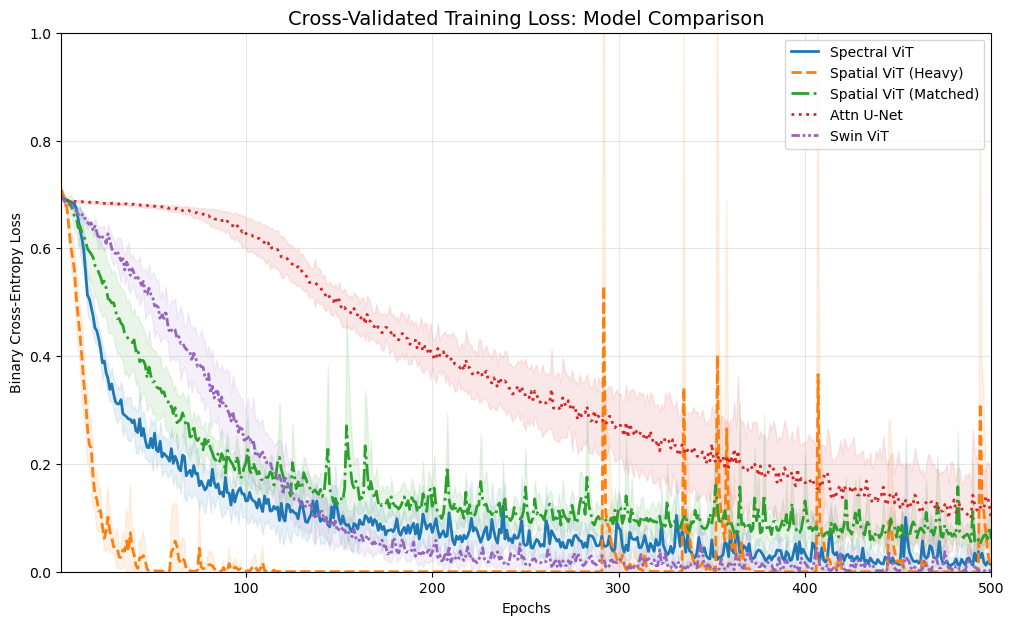

In [5]:
seed_everything(0)

def plot_all_model_losses(history_dict, unet_history, swin_history):
    combined = {**history_dict, **unet_history, **swin_history}
    plt.figure(figsize=(12, 7))
    
    configs = [
        ('spec_loss', 'Spectral ViT', 'tab:blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'tab:orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'tab:green', '-.'),
        ('unet_loss', 'Attn U-Net', 'tab:red', ':'),
        ('swin_loss', 'Swin ViT', 'tab:purple', (0, (3, 1, 1, 1, 1, 1))),
    ]
    
    for key, label, color, style in configs:
        if key in combined and len(combined[key]) > 0:
            data = np.array(combined[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.xlim([1, EPOCHS])
    plt.ylim([0, 1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history, unet_history, swin_history)

In [6]:
model_data = {
    'Spectral ViT': oof_probs_spec,
    'Spatial (Heavy)': oof_probs_spat,
    'Spatial (Matched)': oof_probs_spat_matched,
    'Attn U-Net': oof_probs_unet if 'oof_probs_unet' in locals() else None,
    'Swin ViT': oof_probs_swin,
}

param_counts = {
    'Spectral ViT': params_spec,
    'Spatial (Heavy)': params_spat,
    'Spatial (Matched)': params_spat_matched,
    'Attn U-Net': params_unet if 'params_unet' in locals() else 0,
    'Swin ViT': params_swin,
}

def get_metrics_array(y_true, y_probs):
    """Helper to return raw metrics for a single set of arrays."""
    preds = (y_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    acc = (tp + tn) / len(y_true)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_probs)
    return np.array([acc, sens, spec, auc])

y_final = np.concatenate(oof_y_true)
final_stats = {}
per_fold_variation = {}

for name, probs_list in model_data.items():
    if probs_list is None or len(probs_list) == 0: continue
    
    p_final = np.concatenate(probs_list)
    final_stats[name] = get_metrics_array(y_final, p_final)
    fold_metrics = []
    for f in range(len(oof_y_true)):
        fold_metrics.append(get_metrics_array(oof_y_true[f], probs_list[f]))
    per_fold_variation[name] = np.std(fold_metrics, axis=0)


model_names = list(final_stats.keys())
col_width = max(len(name) for name in model_names) + 2 
col_width = max(col_width, 18) 
label_width = 20
total_width = label_width + (col_width + 3) * len(model_names)

print("\n" + "=" * total_width)
header = f"{'Metric (Mean±SD)':<{label_width}} | " + " | ".join([f"{name:^{col_width}}" for name in model_names])
print(header)
print("-" * total_width)

metrics_labels = ['Accuracy', 'Sensitivity', 'Specificity', 'Mean AUC']
for i, label in enumerate(metrics_labels):
    row = f"{label:<{label_width}} | "
    for name in model_names:
        mean_val = final_stats[name][i]
        std_val = per_fold_variation[name][i]
        
        if label == 'Mean AUC':
            cell_text = f"{mean_val:.3f}±{std_val:.3f}"
        else:
            cell_text = f"{mean_val:.3f}±{std_val:.3f}" 
        
        row += f"{cell_text:^{col_width}} | "
    print(row)

print("-" * total_width)
param_row = f"{'Parameters':<{label_width}} | " + " | ".join([f"{param_counts[name]:^{col_width},}" for name in model_names])
print(param_row)
print("=" * total_width)

def run_comparisons(y_true, p_spec, p_other, label):
    _, _, p_delong = delong_roc_test(y_true, p_spec, p_other)
    s_preds, o_preds = (p_spec > 0.5).astype(int), (p_other > 0.5).astype(int)
    spec_correct, other_correct = (s_preds == y_true), (o_preds == y_true)
    b, c = np.sum(spec_correct & ~other_correct), np.sum(~spec_correct & other_correct) 
    p_mcnemar = mcnemar([[0, b], [c, 0]], exact=True).pvalue
    print(f"Spectral vs {label:<20} | DeLong p: {p_delong:.4f} | McNemar p: {p_mcnemar:.4f}")

p_spec_final = np.concatenate(model_data['Spectral ViT'])
print("\nSignificance for spectral ViT):")
sig_line = 85
print("-" * sig_line)
for name in model_names:
    if name == 'Spectral ViT': continue
    run_comparisons(y_final, p_spec_final, np.concatenate(model_data[name]), name)
print("-" * sig_line)


Metric (Mean±SD)     |    Spectral ViT     |   Spatial (Heavy)   |  Spatial (Matched)  |     Attn U-Net      |      Swin ViT      
----------------------------------------------------------------------------------------------------------------------------------
Accuracy             |     0.795±0.029     |     0.670±0.014     |     0.599±0.035     |     0.733±0.077     |     0.631±0.038     | 
Sensitivity          |     0.846±0.060     |     0.702±0.063     |     0.628±0.079     |     0.843±0.172     |     0.625±0.067     | 
Specificity          |     0.732±0.060     |     0.630±0.069     |     0.563±0.024     |     0.598±0.299     |     0.638±0.129     | 
Mean AUC             |     0.842±0.027     |     0.691±0.021     |     0.616±0.059     |     0.826±0.028     |     0.663±0.043     | 
----------------------------------------------------------------------------------------------------------------------------------
Parameters           |       13,169        |       552,449       |    